# Airport Clustering Analysis

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
airports_node_table = pd.read_csv('airports.csv')
airports_node_table

,Unnamed: 0,airport_code,city_name,avg_daily_flights,percent_delayed,num_unique_airlines,unique_airlines,mean_dep_delay,std_dep_delay
0,20,ATL,"Atlanta, GA",875.707182,33.502205,13,"['OO', 'UA', '9E', 'AA', 'WN', 'NK', 'YX', 'DL...",11.095033,52.473641
1,90,DEN,"Denver, CO",826.337017,38.870205,10,"['OO', 'UA', 'AA', 'WN', 'DL', 'F9', 'G4', 'B6...",11.841161,54.011155
2,91,DFW,"Dallas/Fort Worth, TX",823.325967,37.007288,12,"['OO', 'UA', '9E', 'AA', 'YX', 'NK', 'DL', 'F9...",16.483439,63.404770
3,238,ORD,"Chicago, IL",746.911602,34.298881,12,"['OO', 'UA', '9E', 'AA', 'WN', 'NK', 'YX', 'DL...",12.450400,58.942702
4,70,CLT,"Charlotte, NC",572.060773,36.747052,11,"['UA', '9E', 'AA', 'WN', 'NK', 'YX', 'DL', 'F9...",13.555470,56.395242
...,...,...,...,...,...,...,...,...,...
341,9,ADK,"Adak Island, AK",1.000000,29.787234,1,['AS'],-6.000000,39.851900
342,308,SMX,"Santa Maria, CA",1.000000,54.000000,1,['G4'],40.400000,127.132744
343,13,AKN,"King Salmon, AK",1.000000,23.333333,1,['AS'],-31.500000,41.502597
344,49,BRW,"Barrow, AK",1.000000,54.385965,1,['AS'],8.777778,44.596198


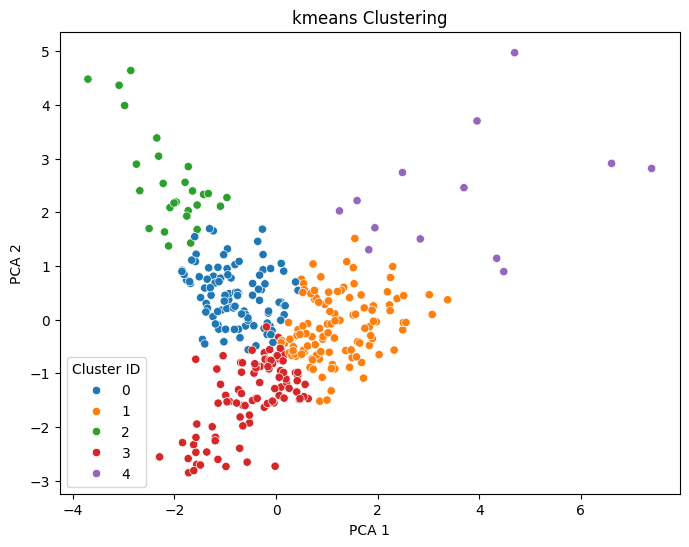

kmeans Silhouette Score: 0.32


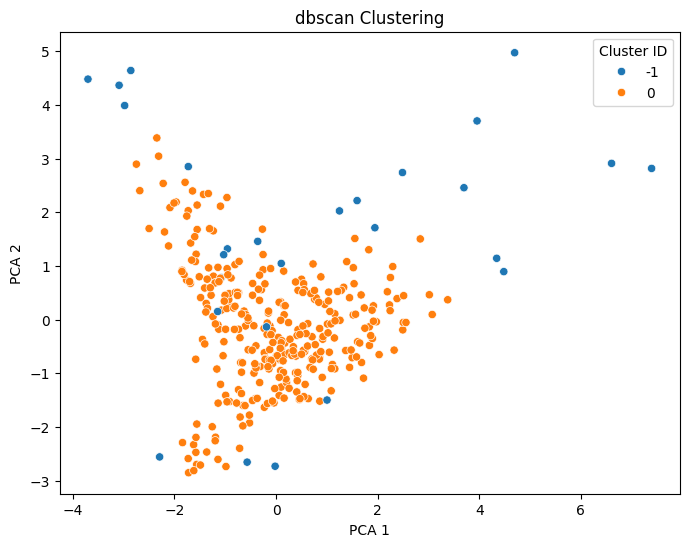

dbscan Silhouette Score: 0.46


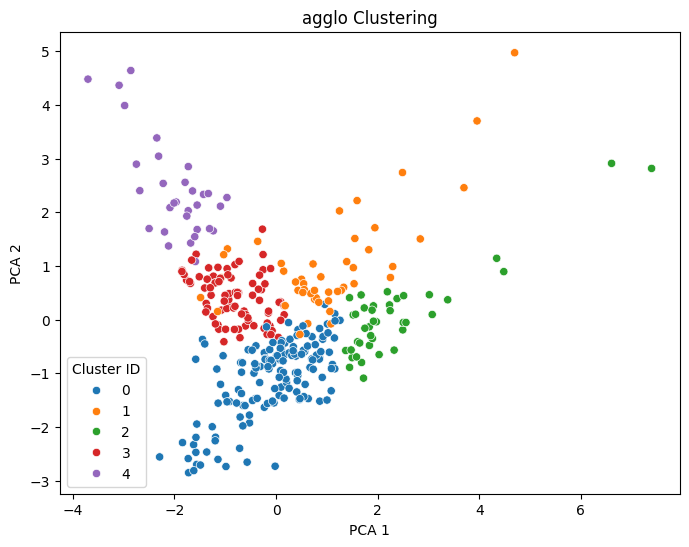

agglo Silhouette Score: 0.29


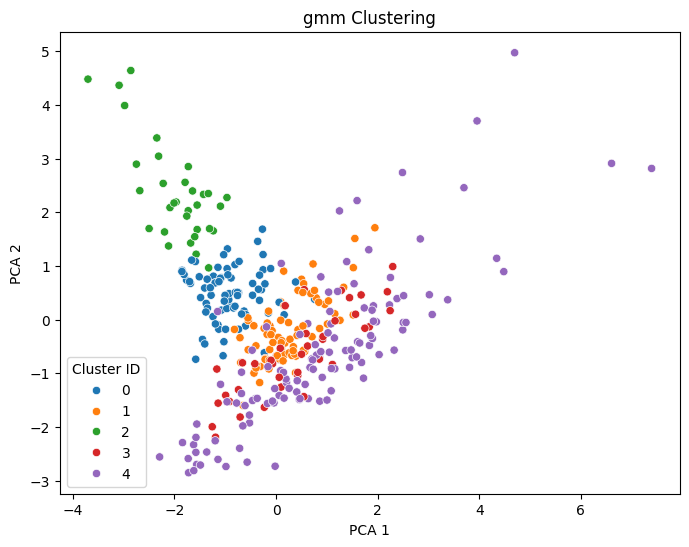

gmm Silhouette Score: 0.06


In [11]:


# Step 1: Prepare features
features = airports_node_table[['avg_daily_flights', 'percent_delayed', 'num_unique_airlines', 'mean_dep_delay', 'std_dep_delay']]
features_scaled = StandardScaler().fit_transform(features)

# Store clustering results
cluster_results = {}

def cluster_and_plot(model, name, labels):
    # Save cluster labels
    airports_node_table[f'{name}_cluster'] = labels
    cluster_results[name] = labels

    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    pca_features = pca.fit_transform(features_scaled)

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=labels, palette='tab10', legend='full')
    plt.title(f'{name} Clustering')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.legend(title='Cluster ID')
    plt.show()

    if hasattr(model, 'labels_') or hasattr(model, 'predict'):
        score = silhouette_score(features_scaled, labels)
        print(f"{name} Silhouette Score: {score:.2f}")
        return score
    else:
        return None


# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(features_scaled)
kmeans_score = cluster_and_plot(kmeans, "kmeans", kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(features_scaled)
dbscan_score = cluster_and_plot(dbscan, "dbscan", dbscan_labels)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(features_scaled)
agg_score = cluster_and_plot(agg, "agglo", agg_labels)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(features_scaled)
gmm_score = cluster_and_plot(gmm, "gmm", gmm_labels)


In [13]:
# Step 4: Choose best model
scores = {
    'kmeans': kmeans_score,
    'dbscan': dbscan_score,
    'agglo': agg_score,
    'gmm': gmm_score
}

best_model_name = max(scores, key=lambda x: scores[x] if scores[x] else -1)
print(f"Best model: {best_model_name} with score {scores[best_model_name]:.2f}")

# Step 5: Add cluster IDs to route-level data
# Create a mapping of airport_code -> cluster_id
airport_cluster_map = dict(zip(
    airports_node_table['airport_code'],
    airports_node_table['kmeans_cluster']
))


Best model: dbscan with score 0.46


In [16]:
routes = pd.read_csv('routes.csv')

In [17]:
# Add to routes dataframe
routes['origin_cluster_id'] = routes['origin'].map(airport_cluster_map)
routes['dest_cluster_id'] = routes['dest'].map(airport_cluster_map)

# View sample
routes[['origin', 'origin_cluster_id', 'dest', 'dest_cluster_id']].head()

,origin,origin_cluster_id,dest,dest_cluster_id
0,BTV,0,JFK,2
1,ROC,0,JFK,2
2,SYR,0,JFK,2
3,SYR,0,DTW,2
4,ITH,3,JFK,2


In [18]:
routes.to_csv('routes_new_final.csv')